# 02 — Knee Provider Exploration

Deeper exploration of the `df_knee_provider` dataset: missing values, 9-patterns, EQ-5D correlations, health conditions, and data cleaning.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Extract columns

df_knee_provider = pd.read_parquet("../data/cleaned/knee-provider-cleaned.parquet")

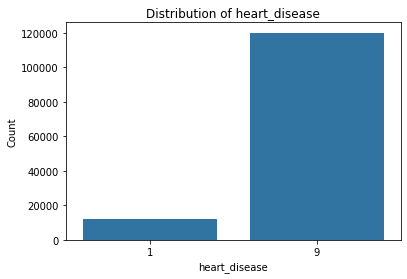


Statistical summary for heart_disease:
heart_disease
9    120083
1     12299
Name: count, dtype: int64



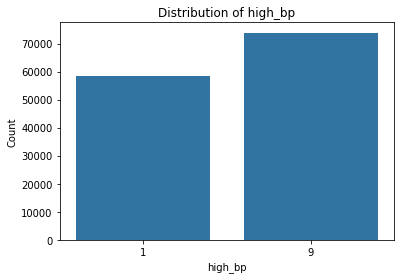


Statistical summary for high_bp:
high_bp
9    73834
1    58548
Name: count, dtype: int64



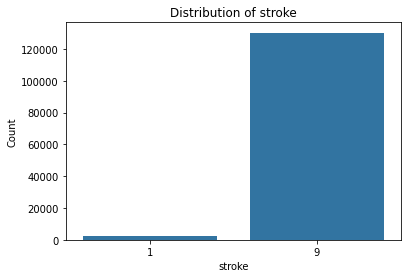


Statistical summary for stroke:
stroke
9    130199
1      2183
Name: count, dtype: int64



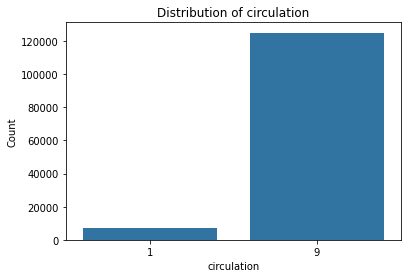


Statistical summary for circulation:
circulation
9    125013
1      7369
Name: count, dtype: int64



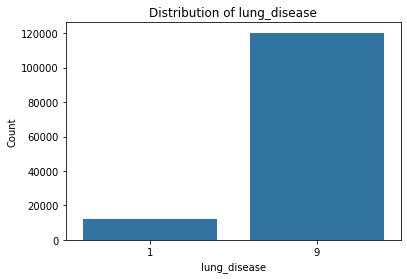


Statistical summary for lung_disease:
lung_disease
9    120287
1     12095
Name: count, dtype: int64



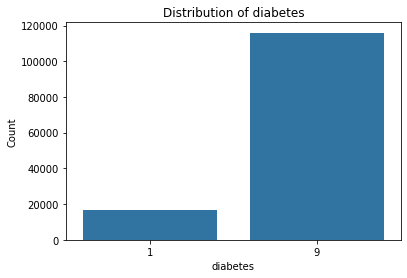


Statistical summary for diabetes:
diabetes
9    115966
1     16416
Name: count, dtype: int64



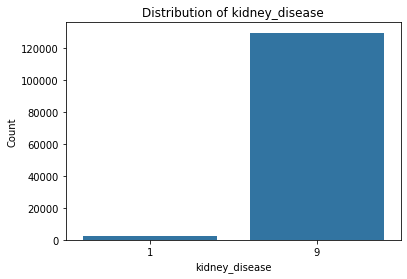


Statistical summary for kidney_disease:
kidney_disease
9    129710
1      2672
Name: count, dtype: int64



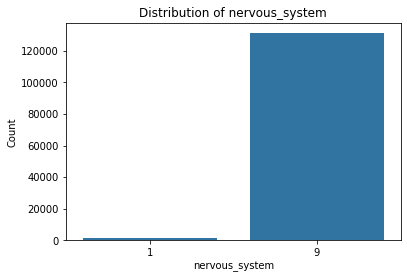


Statistical summary for nervous_system:
nervous_system
9    131041
1      1341
Name: count, dtype: int64



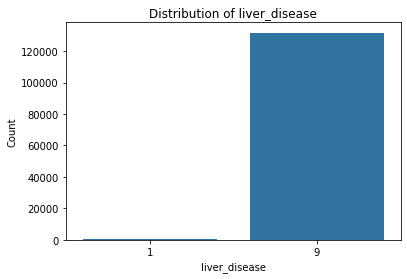


Statistical summary for liver_disease:
liver_disease
9    131618
1       764
Name: count, dtype: int64



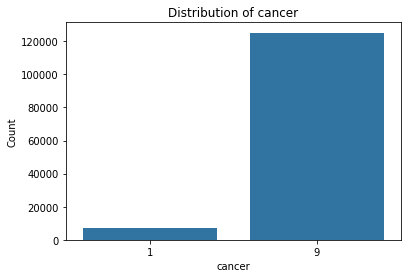


Statistical summary for cancer:
cancer
9    125211
1      7171
Name: count, dtype: int64



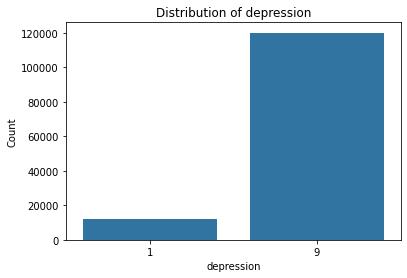


Statistical summary for depression:
depression
9    120144
1     12238
Name: count, dtype: int64



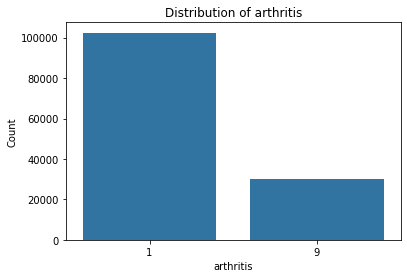


Statistical summary for arthritis:
arthritis
1    102434
9     29948
Name: count, dtype: int64



In [15]:
# Explore these variables visually and statistically:  'heart_disease', 'high_bp', 'stroke', 'circulation', 'lung_disease', 'diabetes', 'kidney_disease', 'nervous_system', 'liver_disease', 'cancer', 'depression', 'arthritis',

df = globals().get("df_knee_provider")
if df is not None:
    health_conditions = [
        'heart_disease', 'high_bp', 'stroke', 'circulation', 
        'lung_disease', 'diabetes', 'kidney_disease', 
        'nervous_system', 'liver_disease', 'cancer', 
        'depression', 'arthritis'
    ]
    
    for condition in health_conditions:
        if condition in df.columns:
            plt.figure(figsize=(6, 4))
            sns.countplot(x=condition, data=df)
            plt.title(f'Distribution of {condition}')
            plt.xlabel(condition)
            plt.ylabel('Count')
            plt.show()
            
            # Statistical summary
            counts = df[condition].value_counts(dropna=False)
            print(f"\nStatistical summary for {condition}:\n{counts}\n")
        else:
            print(f"{condition}: column not found in df_knee_provider")


Delta Summary Table:
 Delta Bin  Percentage  Cumulative Percentage
      <-20    0.053084               0.053084
-20 to -10    0.583923               0.637006
 -10 to -5    1.324789               1.961795
   -5 to 0    3.433526               5.395321
    0 to 5    7.058615              12.453936
   5 to 10   11.993876              24.447812
  10 to 20   37.456437              61.904249
       >20   38.095751             100.000000


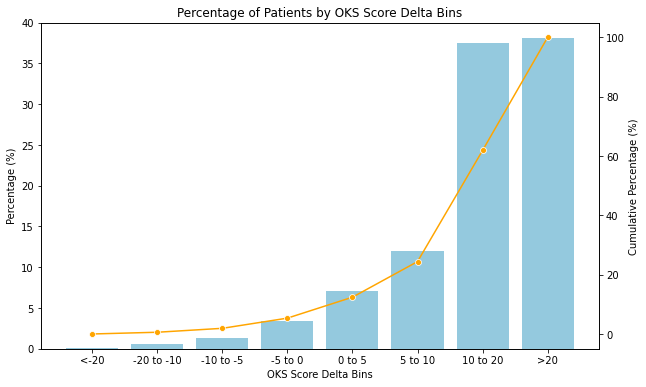

In [16]:
# Calculate the percentage of patients in df_knee_provider for delta per each bin, make it a summary table and visualize it with percentages and make it cumulative

df_knee = globals().get("df_knee_provider")

# Define bins for delta
bins = [-np.inf, -20, -10, -5, 0, 5, 10, 20, np.inf]
labels = ['<-20', '-20 to -10', '-10 to -5', '-5 to 0', '0 to 5', '5 to 10', '10 to 20', '>20']

if df_knee is not None:
    # Filter for patients with both scores filled
    df_knee_filtered = df_knee.dropna(subset=['oks_t0_score', 'oks_t1_score']).copy()
    # Calculate delta
    df_knee_filtered['oks_delta'] = df_knee_filtered['oks_t1_score'] - df_knee_filtered['oks_t0_score']
    
    # Bin the delta values
    df_knee_filtered['delta_bin'] = pd.cut(df_knee_filtered['oks_delta'], bins=bins, labels=labels)
    
    # Calculate percentage per bin
    delta_summary = df_knee_filtered['delta_bin'].value_counts(normalize=True).sort_index() * 100
    delta_summary = delta_summary.reset_index()
    delta_summary.columns = ['Delta Bin', 'Percentage']
    
    # Calculate cumulative percentage
    delta_summary['Cumulative Percentage'] = delta_summary['Percentage'].cumsum()
    
    print("\nDelta Summary Table:")
    print(delta_summary.to_string(index=False))
    
    # Visualize the summary
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Delta Bin', y='Percentage', data=delta_summary, color='skyblue')
    plt.title('Percentage of Patients by OKS Score Delta Bins')
    plt.xlabel('OKS Score Delta Bins')
    plt.ylabel('Percentage (%)')
    
    # Add cumulative percentage line
    plt.twinx()
    sns.lineplot(x='Delta Bin', y='Cumulative Percentage', data=delta_summary, color='orange', marker='o')
    plt.ylabel('Cumulative Percentage (%)')
    
    plt.show()

# Feature Engineering and Analysis for OKS Outcome Classification

**Objective**: Build features for a classification model that predicts poor outcomes based on OKS score changes.

**Target Variable Definition**:
- **Good Outcome (1)**: OKS improvement (t1 - t0) >= 7 points
- **Poor Outcome (0)**: OKS improvement (t1 - t0) < 7 points

**Key Principles**:
- No data leakage: Only use information available before/at surgery time (t0)
- Avoid using post-surgery outcomes (t1 scores, complications after surgery)
- Focus on baseline characteristics, pre-surgery health, and surgical factors

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully")

Libraries imported successfully


## 1. Data Loading and Initial Exploration

In [2]:
# Load the cleaned data
data_path = '../data/cleaned/knee-provider-cleaned.parquet'
df = pd.read_parquet(data_path)

print(f"Dataset shape: {df.shape}")
print(f"\nNumber of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")

Dataset shape: (132382, 81)

Number of rows: 132,382
Number of columns: 81


In [18]:
# Display first few rows
df.head()

,provider_code,procedure,revision_flag,year,age_band,gender,t0_assisted,t0_assisted_by,t0_symptom_period,t0_previous_surgery,...,oks_t1_walking,oks_t1_standing,oks_t1_limping,oks_t1_kneeling,oks_t1_work,oks_t1_confidence,oks_t1_shopping,oks_t1_stairs,oks_t1_score,oks_oks_t1_predicted
0,ADP02,Knee Replacement,0,2018/19,NaN,NaN,2,0,2,2,...,3,3,4,2,4,4,4,3,40.0,34.825798
1,ADP02,Knee Replacement,0,2018/19,NaN,NaN,2,0,2,2,...,4,4,4,3,3,3,4,4,44.0,43.180367
2,ADP02,Knee Replacement,0,2018/19,NaN,NaN,2,0,2,2,...,4,4,4,2,4,4,4,4,46.0,42.201862
3,ADP02,Knee Replacement,0,2018/19,NaN,NaN,2,0,2,2,...,1,4,4,1,3,3,4,3,36.0,36.826900
4,ADP02,Knee Replacement,0,2018/19,NaN,NaN,1,0,3,2,...,2,3,3,2,2,3,2,1,28.0,33.434299


In [19]:
# Data types and memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 132382 entries, 0 to 139235
Data columns (total 81 columns):
 #   Column                        Non-Null Count   Dtype   
---  ------                        --------------   -----   
 0   provider_code                 132382 non-null  category
 1   procedure                     132382 non-null  category
 2   revision_flag                 132382 non-null  uint8   
 3   year                          132382 non-null  category
 4   age_band                      123354 non-null  category
 5   gender                        123354 non-null  float32 
 6   t0_assisted                   132382 non-null  uint8   
 7   t0_assisted_by                132382 non-null  uint8   
 8   t0_symptom_period             132382 non-null  uint8   
 9   t0_previous_surgery           132382 non-null  uint8   
 10  t0_living_arrangements        132382 non-null  uint8   
 11  t0_disability                 132382 non-null  uint8   
 12  heart_disease                 13238

In [20]:
# Statistical summary
df.describe()

,revision_flag,gender,t0_assisted,t0_assisted_by,t0_symptom_period,t0_previous_surgery,t0_living_arrangements,t0_disability,heart_disease,high_bp,...,oks_t1_walking,oks_t1_standing,oks_t1_limping,oks_t1_kneeling,oks_t1_work,oks_t1_confidence,oks_t1_shopping,oks_t1_stairs,oks_t1_score,oks_oks_t1_predicted
count,132382.0,123354.000000,132382.000000,132382.0,132382.000000,132382.000000,132382.000000,132382.000000,132382.000000,132382.000000,...,132382.000000,132382.000000,132382.000000,132382.000000,132382.000000,132382.000000,132382.000000,132382.000000,129983.000000,128931.000000
mean,0.0,1.572304,1.921039,0.0,2.649756,2.005295,1.345999,1.815496,8.256757,5.461875,...,3.411801,3.141938,3.147868,1.676436,3.113973,3.548383,3.233060,3.085125,36.143318,34.673317
std,0.0,0.494747,0.815967,0.0,1.031559,0.617852,1.027073,1.581115,2.322407,3.973259,...,1.115834,1.011155,1.190938,1.479360,1.097922,0.928941,1.269813,1.128362,9.301224,4.464723
min,0.0,1.000000,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.453117
25%,0.0,1.000000,2.000000,0.0,2.000000,2.000000,1.000000,1.000000,9.000000,1.000000,...,3.000000,3.000000,3.000000,0.000000,2.000000,3.000000,3.000000,2.000000,31.000000,31.839390
50%,0.0,2.000000,2.000000,0.0,2.000000,2.000000,1.000000,2.000000,9.000000,9.000000,...,4.000000,3.000000,3.000000,2.000000,3.000000,4.000000,4.000000,3.000000,38.000000,35.221458
75%,0.0,2.000000,2.000000,0.0,3.000000,2.000000,1.000000,2.000000,9.000000,9.000000,...,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,4.000000,4.000000,44.000000,38.079254
max,0.0,2.000000,9.000000,0.0,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,...,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,48.000000,44.520660


## 2. Create Target Variable (No Data Leakage)

**CRITICAL**: The target variable calculation uses t1 scores, but this is ONLY for creating the label.
We will NOT use oks_t1_score or any post-surgery outcomes as features in the model.

In [21]:
# Check if OKS scores exist
print("Available columns:")
print([col for col in df.columns if 'oks' in col.lower()])

Available columns:
['oks_eq_5d_index_t1_predicted', 'oks_eq_vas_t1_predicted', 'oks_t0_pain', 'oks_t0_night_pain', 'oks_t0_washing', 'oks_t0_transport', 'oks_t0_walking', 'oks_t0_standing', 'oks_t0_limping', 'oks_t0_kneeling', 'oks_t0_work', 'oks_t0_confidence', 'oks_t0_shopping', 'oks_t0_stairs', 'oks_t0_score', 'oks_t1_pain', 'oks_t1_night_pain', 'oks_t1_washing', 'oks_t1_transport', 'oks_t1_walking', 'oks_t1_standing', 'oks_t1_limping', 'oks_t1_kneeling', 'oks_t1_work', 'oks_t1_confidence', 'oks_t1_shopping', 'oks_t1_stairs', 'oks_t1_score', 'oks_oks_t1_predicted']


In [42]:
# Create target variable
# Good outcome (1): improvement >= 7 points
# Poor outcome (0): improvement < 7 points

df['oks_improvement'] = df['oks_t1_score'] - df['oks_t0_score']
df['target'] = (df['oks_improvement'] <= 7).astype(int)

print("Target Variable Distribution:")
print(df['target'].value_counts())
print("\nPercentage Distribution:")
print(df['target'].value_counts(normalize=True) * 100)

Target Variable Distribution:
target
0    110909
1     21473
Name: count, dtype: int64

Percentage Distribution:
target
0    83.779517
1    16.220483
Name: proportion, dtype: float64


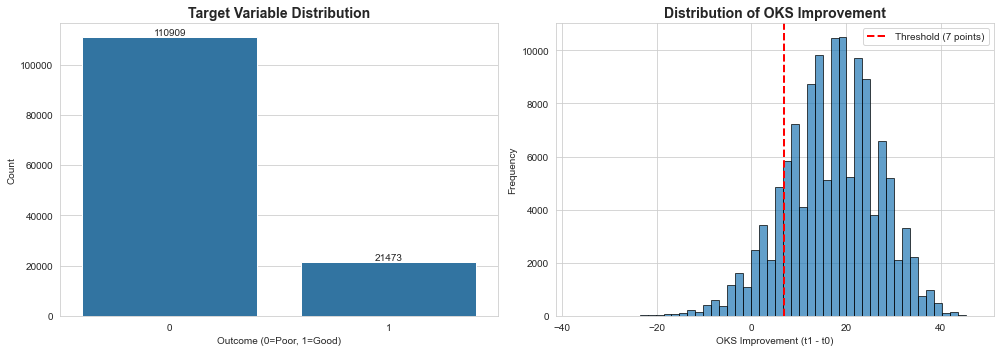


OKS Improvement Statistics:
count    129983.000000
mean         17.040813
std           9.793470
min         -37.000000
25%          11.000000
50%          18.000000
75%          24.000000
max          47.000000
Name: oks_improvement, dtype: float64


In [23]:
# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(data=df, x='target', ax=axes[0])
axes[0].set_title('Target Variable Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Outcome (0=Poor, 1=Good)')
axes[0].set_ylabel('Count')

# Add percentages on bars
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d')

# Distribution of OKS improvement
axes[1].hist(df['oks_improvement'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=7, color='red', linestyle='--', linewidth=2, label='Threshold (7 points)')
axes[1].set_title('Distribution of OKS Improvement', fontsize=14, fontweight='bold')
axes[1].set_xlabel('OKS Improvement (t1 - t0)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nOKS Improvement Statistics:")
print(df['oks_improvement'].describe())

## 3. Identify Feature Categories and Data Leakage Risks

In [24]:
# Categorize features by leakage risk

# SAFE FEATURES (can be used) - available before/at surgery
safe_demographic = [col for col in df.columns if any(x in col.lower() for x in ['age', 'gender', 'sex'])]
safe_baseline_health = [col for col in df.columns if 't0' in col.lower() and 'oks' not in col.lower()]
safe_baseline_oks = ['oks_t0_score']  # Baseline OKS is safe
safe_surgery = [col for col in df.columns if any(x in col.lower() for x in ['procedure', 'side', 'previous', 'revision'])]
safe_provider = [col for col in df.columns if any(x in col.lower() for x in ['provider', 'hospital', 'volume'])]

# LEAKAGE FEATURES (MUST NOT be used as features)
leakage_features = [
    'oks_t1_score',  # Post-surgery outcome
    'oks_improvement',  # Derived from t1
    'target'  # The label itself
]
leakage_features += [col for col in df.columns if 't1' in col.lower() and col not in ['oks_t1_score']]
leakage_features += [col for col in df.columns if any(x in col.lower() for x in ['complication', 'readmission', 'revision']) and 't0' not in col.lower()]

print("=" * 80)
print("FEATURE CATEGORIZATION FOR DATA LEAKAGE PREVENTION")
print("=" * 80)

print("\n✓ SAFE FEATURES (Can be used):")
print("\n  Demographic:")
for col in safe_demographic:
    print(f"    - {col}")

print("\n  Baseline Health (t0):")
for col in safe_baseline_health[:10]:  # Show first 10
    print(f"    - {col}")
if len(safe_baseline_health) > 10:
    print(f"    ... and {len(safe_baseline_health) - 10} more")

print("\n  Baseline OKS:")
for col in safe_baseline_oks:
    print(f"    - {col}")

print("\n  Surgery Details:")
for col in safe_surgery:
    print(f"    - {col}")

print("\n\n✗ LEAKAGE FEATURES (Must NOT be used):")
for col in leakage_features:
    if col in df.columns:
        print(f"    - {col}")

print("\n" + "=" * 80)

FEATURE CATEGORIZATION FOR DATA LEAKAGE PREVENTION

✓ SAFE FEATURES (Can be used):

  Demographic:
    - age_band
    - gender

  Baseline Health (t0):
    - t0_assisted
    - t0_assisted_by
    - t0_symptom_period
    - t0_previous_surgery
    - t0_living_arrangements
    - t0_disability
    - t0_mobility
    - t0_self_care
    - t0_activity
    - t0_discomfort
    ... and 4 more

  Baseline OKS:
    - oks_t0_score

  Surgery Details:
    - procedure
    - revision_flag
    - t0_previous_surgery


✗ LEAKAGE FEATURES (Must NOT be used):
    - oks_t1_score
    - oks_improvement
    - target
    - t1_assisted
    - t1_assisted_by
    - t1_living_arrangements
    - t1_disability
    - t1_mobility
    - t1_self_care
    - t1_activity
    - t1_discomfort
    - t1_anxiety
    - t1_satisfaction
    - t1_sucess
    - t1_allergy
    - t1_bleeding
    - t1_wound
    - t1_urine
    - t1_further_surgery
    - t1_readmitted
    - t1_eq5d_index_profile
    - t1_eq5d_index
    - oks_eq_5d_index_t1_pr

In [25]:
# Get all column names for detailed analysis
all_columns = df.columns.tolist()
print(f"\nTotal columns: {len(all_columns)}")
print("\nAll columns:")
for i, col in enumerate(all_columns, 1):
    print(f"{i:3d}. {col}")


Total columns: 83

All columns:
  1. provider_code
  2. procedure
  3. revision_flag
  4. year
  5. age_band
  6. gender
  7. t0_assisted
  8. t0_assisted_by
  9. t0_symptom_period
 10. t0_previous_surgery
 11. t0_living_arrangements
 12. t0_disability
 13. heart_disease
 14. high_bp
 15. stroke
 16. circulation
 17. lung_disease
 18. diabetes
 19. kidney_disease
 20. nervous_system
 21. liver_disease
 22. cancer
 23. depression
 24. arthritis
 25. t0_mobility
 26. t0_self_care
 27. t0_activity
 28. t0_discomfort
 29. t0_anxiety
 30. t0_eq5d_index_profile
 31. t0_eq5d_index
 32. t1_assisted
 33. t1_assisted_by
 34. t1_living_arrangements
 35. t1_disability
 36. t1_mobility
 37. t1_self_care
 38. t1_activity
 39. t1_discomfort
 40. t1_anxiety
 41. t1_satisfaction
 42. t1_sucess
 43. t1_allergy
 44. t1_bleeding
 45. t1_wound
 46. t1_urine
 47. t1_further_surgery
 48. t1_readmitted
 49. t1_eq5d_index_profile
 50. t1_eq5d_index
 51. oks_eq_5d_index_t1_predicted
 52. t0_eq_vas
 53. t1_eq_v

## 4. Missing Values Analysis

In [26]:
# Calculate missing values
missing_df = pd.DataFrame({
    'column': df.columns,
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().sum() / len(df)) * 100,
    'dtype': df.dtypes
}).sort_values('missing_pct', ascending=False)

# Filter to show only columns with missing values
missing_df_filtered = missing_df[missing_df['missing_count'] > 0]

print("Missing Values Summary:")
print(missing_df_filtered.to_string())

Missing Values Summary:
                                                    column  missing_count  missing_pct     dtype
oks_eq_vas_t1_predicted            oks_eq_vas_t1_predicted          18198    13.746582   float32
oks_eq_5d_index_t1_predicted  oks_eq_5d_index_t1_predicted          13334    10.072366   float32
age_band                                          age_band           9028     6.819658  category
gender                                              gender           9028     6.819658   float32
t0_eq5d_index                                t0_eq5d_index           6989     5.279419   float32
t1_eq5d_index                                t1_eq5d_index           5880     4.441691   float32
oks_oks_t1_predicted                  oks_oks_t1_predicted           3451     2.606850   float32
oks_improvement                            oks_improvement           2399     1.812180   float32
oks_t1_score                                  oks_t1_score           2399     1.812180   float32


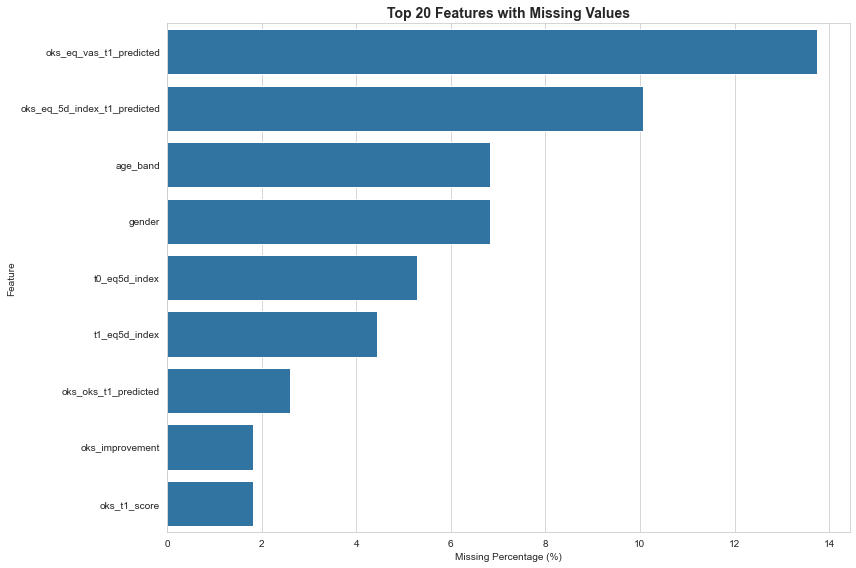

In [27]:
# Visualize missing values for top features
if len(missing_df_filtered) > 0:
    top_missing = missing_df_filtered.head(20)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.barplot(data=top_missing, y='column', x='missing_pct', ax=ax)
    ax.set_title('Top 20 Features with Missing Values', fontsize=14, fontweight='bold')
    ax.set_xlabel('Missing Percentage (%)')
    ax.set_ylabel('Feature')
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in the dataset!")

## 5. Exploratory Data Analysis of Safe Features

### 5.1 Baseline OKS Score Analysis

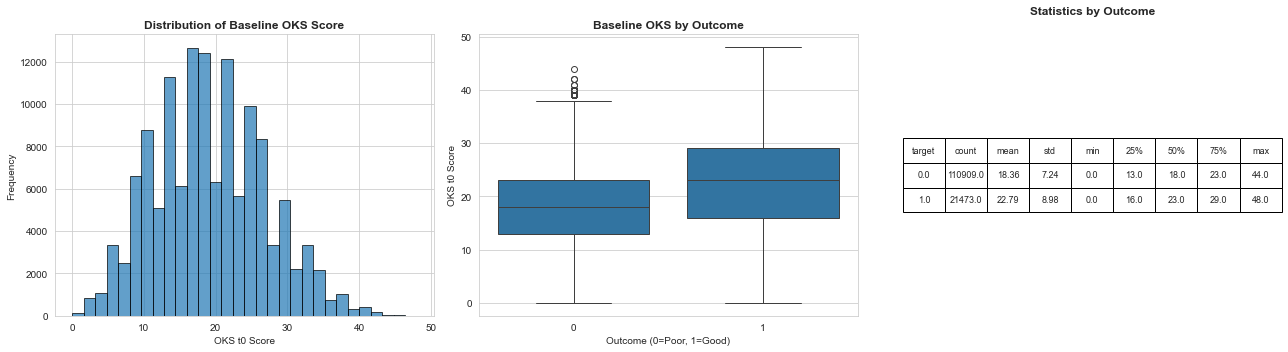


Mann-Whitney U test:
  Test statistic: 844601893.50
  P-value: 0.0000
  Significant at α=0.05: True


In [28]:
# Analyze baseline OKS score
if 'oks_t0_score' in df.columns:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Distribution
    axes[0].hist(df['oks_t0_score'].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[0].set_title('Distribution of Baseline OKS Score', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('OKS t0 Score')
    axes[0].set_ylabel('Frequency')
    
    # By target
    df_plot = df.dropna(subset=['oks_t0_score', 'target'])
    sns.boxplot(data=df_plot, x='target', y='oks_t0_score', ax=axes[1])
    axes[1].set_title('Baseline OKS by Outcome', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Outcome (0=Poor, 1=Good)')
    axes[1].set_ylabel('OKS t0 Score')
    
    # Statistics by target
    stats_by_target = df_plot.groupby('target')['oks_t0_score'].describe()
    axes[2].axis('off')
    table_data = stats_by_target.round(2).reset_index()
    table = axes[2].table(cellText=table_data.values, colLabels=table_data.columns,
                          cellLoc='center', loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2)
    axes[2].set_title('Statistics by Outcome', fontsize=12, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.show()
    
    # Statistical test
    poor_oks = df[df['target'] == 0]['oks_t0_score'].dropna()
    good_oks = df[df['target'] == 1]['oks_t0_score'].dropna()
    
    if len(poor_oks) > 0 and len(good_oks) > 0:
        statistic, pvalue = stats.mannwhitneyu(poor_oks, good_oks, alternative='two-sided')
        print(f"\nMann-Whitney U test:")
        print(f"  Test statistic: {statistic:.2f}")
        print(f"  P-value: {pvalue:.4f}")
        print(f"  Significant at α=0.05: {pvalue < 0.05}")

### 5.2 Demographic Features Analysis

In [29]:
# Analyze demographic features
demographic_cols = [col for col in df.columns if any(x in col.lower() for x in ['age', 'gender', 'sex'])]

print("Demographic Features:")
for col in demographic_cols:
    print(f"\n{col}:")
    if df[col].dtype in ['object', 'category']:
        print(df[col].value_counts())
        print(f"\nBy outcome:")
        print(pd.crosstab(df[col], df['target'], normalize='index') * 100)
    else:
        print(df[col].describe())
        print(f"\nBy outcome:")
        print(df.groupby('target')[col].describe())

Demographic Features:

age_band:
age_band
70 to 79     52211
60 to 69     43270
80 to 89     15007
50 to 59     12614
40 to 49       230
90 to 120       22
Name: count, dtype: int64

By outcome:
target             0          1
age_band                       
40 to 49   82.173913  17.826087
50 to 59   81.576027  18.423973
60 to 69   83.498960  16.501040
70 to 79   84.564555  15.435445
80 to 89   84.567202  15.432798
90 to 120  95.454545   4.545455

gender:
count    123354.000000
mean          1.572304
std           0.494747
min           1.000000
25%           1.000000
50%           2.000000
75%           2.000000
max           2.000000
Name: gender, dtype: float64

By outcome:
           count      mean       std  min  25%  50%  75%  max
target                                                       
0       103473.0  1.577706  0.493927  1.0  1.0  2.0  2.0  2.0
1        19881.0  1.544188  0.498056  1.0  1.0  2.0  2.0  2.0


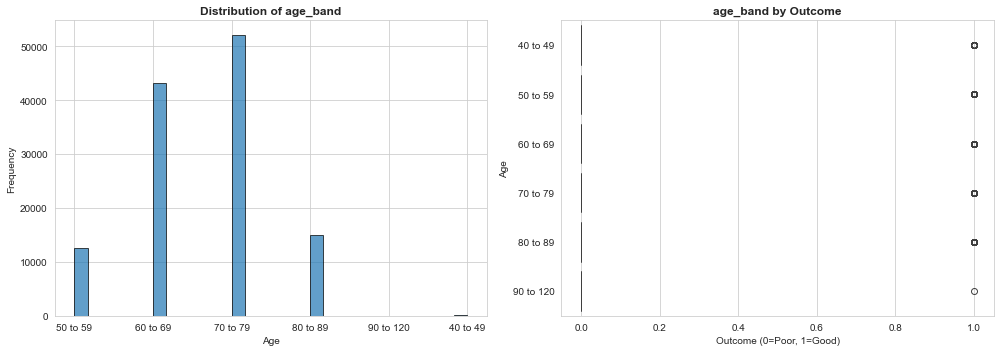

In [30]:
# Visualize age distribution if available
age_cols = [col for col in df.columns if 'age' in col.lower()]

if age_cols:
    age_col = age_cols[0]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Overall distribution
    axes[0].hist(df[age_col].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[0].set_title(f'Distribution of {age_col}', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Age')
    axes[0].set_ylabel('Frequency')
    
    # By outcome
    df_plot = df.dropna(subset=[age_col, 'target'])
    sns.boxplot(data=df_plot, x='target', y=age_col, ax=axes[1])
    axes[1].set_title(f'{age_col} by Outcome', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Outcome (0=Poor, 1=Good)')
    axes[1].set_ylabel('Age')
    
    plt.tight_layout()
    plt.show()

### 5.3 Comorbidities and Health Conditions

In [31]:
# Identify comorbidity columns (only t0 - baseline)
comorbidity_cols = [col for col in df.columns if any(x in col.lower() for x in 
    ['comorbidity', 'diabetes', 'heart', 'cardiovascular', 'respiratory', 'bmi', 'weight', 'smoker', 'smoking'])]
comorbidity_cols = [col for col in comorbidity_cols if 't1' not in col.lower()]  # Exclude post-surgery

print(f"Comorbidity/Health Features Found: {len(comorbidity_cols)}")
for col in comorbidity_cols:
    print(f"  - {col}")

Comorbidity/Health Features Found: 2
  - heart_disease
  - diabetes


In [32]:
# Analyze each comorbidity feature
for col in comorbidity_cols[:5]:  # Show first 5
    print(f"\n{'='*80}")
    print(f"Feature: {col}")
    print(f"{'='*80}")
    
    if df[col].dtype in ['object', 'category', 'bool']:
        print("\nValue counts:")
        print(df[col].value_counts(dropna=False))
        
        print("\nOutcome rate by category:")
        ct = pd.crosstab(df[col], df['target'], normalize='index') * 100
        print(ct)
    else:
        print("\nStatistics:")
        print(df[col].describe())
        
        print("\nBy outcome:")
        print(df.groupby('target')[col].describe())


Feature: heart_disease

Statistics:
count    132382.000000
mean          8.256757
std           2.322407
min           1.000000
25%           9.000000
50%           9.000000
75%           9.000000
max           9.000000
Name: heart_disease, dtype: float64

By outcome:
           count      mean       std  min  25%  50%  75%  max
target                                                       
0       110909.0  8.275803  2.295466  1.0  9.0  9.0  9.0  9.0
1        21473.0  8.158385  2.454564  1.0  9.0  9.0  9.0  9.0

Feature: diabetes

Statistics:
count    132382.000000
mean          8.007962
std           2.636706
min           1.000000
25%           9.000000
50%           9.000000
75%           9.000000
max           9.000000
Name: diabetes, dtype: float64

By outcome:
           count      mean       std  min  25%  50%  75%  max
target                                                       
0       110909.0  8.043035  2.596150  1.0  9.0  9.0  9.0  9.0
1        21473.0  7.826806  2.830113

## 6. Correlation Analysis (Safe Features Only)

In [33]:
# Select only safe numerical features for correlation
safe_numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Remove leakage features
safe_numerical_cols = [col for col in safe_numerical_cols if col not in leakage_features]

# Include target for correlation analysis
if 'target' not in safe_numerical_cols:
    safe_numerical_cols.append('target')

print(f"Safe numerical features for correlation: {len(safe_numerical_cols)}")
print(safe_numerical_cols[:20])  # Show first 20

Safe numerical features for correlation: 41
['gender', 't0_assisted', 't0_assisted_by', 't0_symptom_period', 't0_previous_surgery', 't0_living_arrangements', 't0_disability', 'heart_disease', 'high_bp', 'stroke', 'circulation', 'lung_disease', 'diabetes', 'kidney_disease', 'nervous_system', 'liver_disease', 'cancer', 'depression', 'arthritis', 't0_mobility']


In [34]:
# Calculate correlation with target
if len(safe_numerical_cols) > 1:
    correlations = df[safe_numerical_cols].corr()['target'].sort_values(ascending=False)
    correlations = correlations[correlations.index != 'target']  # Remove self-correlation
    
    print("Top 20 Features Correlated with Target:")
    print(correlations.head(20))
    
    print("\nBottom 20 Features Correlated with Target:")
    print(correlations.tail(20))

Top 20 Features Correlated with Target:
oks_t0_limping            0.219964
oks_t0_score              0.211726
oks_t0_pain               0.177756
oks_t0_work               0.168533
oks_t0_standing           0.162954
oks_t0_stairs             0.145955
oks_t0_walking            0.135542
oks_t0_transport          0.133462
oks_t0_shopping           0.131298
oks_t0_kneeling           0.130962
oks_t0_confidence         0.122158
oks_t0_night_pain         0.117792
t0_eq5d_index             0.096353
oks_t0_washing            0.080865
arthritis                 0.019458
t0_eq_vas                 0.015636
t0_anxiety                0.012194
t0_disability             0.010172
t0_living_arrangements    0.008387
t0_assisted               0.006995
Name: target, dtype: float64

Bottom 20 Features Correlated with Target:
high_bp                  0.003993
t0_self_care             0.002452
cancer                   0.001464
kidney_disease          -0.006643
nervous_system          -0.007670
t0_previous_surge

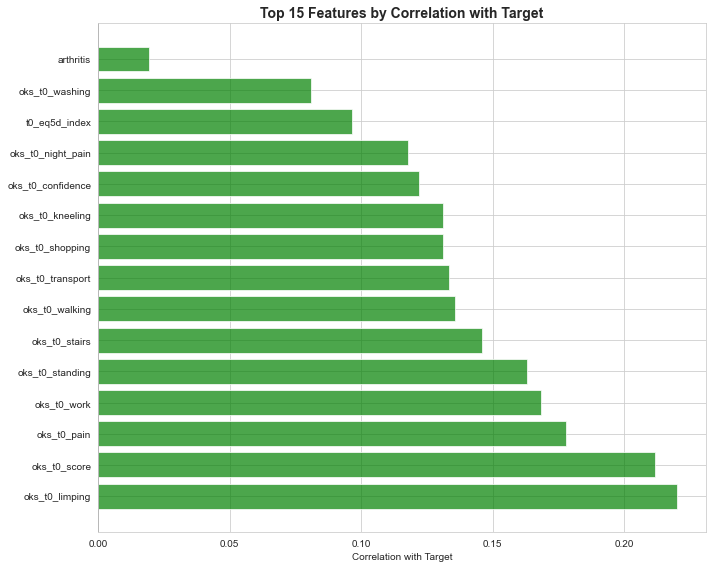

In [35]:
# Visualize top correlations
if len(safe_numerical_cols) > 1:
    top_corr = correlations.head(15)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    colors = ['green' if x > 0 else 'red' for x in top_corr.values]
    ax.barh(range(len(top_corr)), top_corr.values, color=colors, alpha=0.7)
    ax.set_yticks(range(len(top_corr)))
    ax.set_yticklabels(top_corr.index)
    ax.set_xlabel('Correlation with Target')
    ax.set_title('Top 15 Features by Correlation with Target', fontsize=14, fontweight='bold')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    plt.tight_layout()
    plt.show()

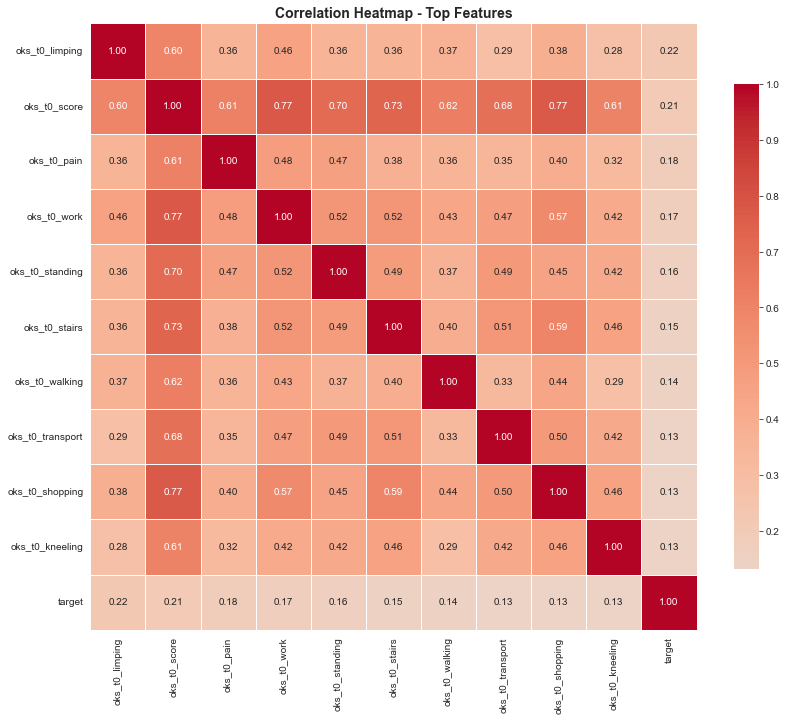

In [36]:
# Correlation heatmap for top features
if len(safe_numerical_cols) > 1:
    top_features = correlations.head(10).index.tolist() + ['target']
    
    if 'oks_t0_score' not in top_features:
        top_features.insert(0, 'oks_t0_score')
    
    corr_matrix = df[top_features].corr()
    
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
    ax.set_title('Correlation Heatmap - Top Features', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [39]:
# Final data quality summary
print("="*80)
print("DATA QUALITY SUMMARY")
print("="*80)

# Missing values
missing_summary = df.isnull().sum().sort_values(ascending=False)
missing_summary = missing_summary[missing_summary > 0]
print(f"\nFeatures with missing values: {len(missing_summary)}")
if len(missing_summary) > 0:
    print("\nTop 10 features by missing count:")
    print(missing_summary.head(10))

# Duplicates
duplicates = df.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")

# Target distribution
print("\nTarget distribution:")
target_dist = df['target'].value_counts()
print(target_dist)
print(f"\nClass balance ratio: {target_dist.min() / target_dist.max():.2f}")

# Data types
print("\nData types distribution:")
print(df.dtypes.value_counts())

print("\n" + "="*80)
print("FEATURE ENGINEERING COMPLETE")
print("="*80)

DATA QUALITY SUMMARY

Features with missing values: 9

Top 10 features by missing count:
oks_eq_vas_t1_predicted         18198
oks_eq_5d_index_t1_predicted    13334
age_band                         9028
gender                           9028
t0_eq5d_index                    6989
t1_eq5d_index                    5880
oks_oks_t1_predicted             3451
oks_improvement                  2399
oks_t1_score                     2399
dtype: int64

Duplicate rows: 0

Target distribution:
target
0    110909
1     21473
Name: count, dtype: int64

Class balance ratio: 0.19

Data types distribution:
uint8       65
float32      9
int64        3
uint16       2
category     1
category     1
category     1
category     1
Name: count, dtype: int64

FEATURE ENGINEERING COMPLETE


In [40]:
# Analyze variables for potential 9-based missing value indicators
# We'll check for patterns like 9, 99, 999, 9999 that might indicate missing values

def analyze_nine_patterns(df):
    """
    Analyze each column to detect if it uses 9-based patterns as missing indicators.
    Returns a DataFrame with columns that have suspicious 9-based patterns.
    """
    results = []
    
    for col in df.columns:
        col_data = df[col]
        
        # Skip non-numeric columns
        if not pd.api.types.is_numeric_dtype(col_data):
            continue
        
        # Get value counts
        value_counts = col_data.value_counts().sort_index()
        
        # Check for common missing value patterns
        patterns = {
            'has_9': 9 in value_counts.index,
            'has_99': 99 in value_counts.index,
            'has_999': 999 in value_counts.index,
            'has_9999': 9999 in value_counts.index,
            'count_9': value_counts.get(9, 0),
            'count_99': value_counts.get(99, 0),
            'count_999': value_counts.get(999, 0),
            'count_9999': value_counts.get(9999, 0),
        }
        
        # Calculate percentages
        total = len(col_data)
        patterns['pct_9'] = (patterns['count_9'] / total * 100) if patterns['count_9'] > 0 else 0
        patterns['pct_99'] = (patterns['count_99'] / total * 100) if patterns['count_99'] > 0 else 0
        patterns['pct_999'] = (patterns['count_999'] / total * 100) if patterns['count_999'] > 0 else 0
        patterns['pct_9999'] = (patterns['count_9999'] / total * 100) if patterns['count_9999'] > 0 else 0
        
        # Check if any 9-pattern exists
        has_any_pattern = any([patterns['has_9'], patterns['has_99'], 
                               patterns['has_999'], patterns['has_9999']])
        
        if has_any_pattern:
            # Get basic stats
            patterns['column'] = col
            patterns['dtype'] = str(col_data.dtype)
            patterns['unique_values'] = col_data.nunique()
            patterns['min'] = col_data.min()
            patterns['max'] = col_data.max()
            patterns['mean'] = col_data.mean()
            patterns['median'] = col_data.median()
            patterns['total_count'] = total
            patterns['actual_missing'] = col_data.isnull().sum()
            
            results.append(patterns)
    
    return pd.DataFrame(results)

print("Analyzing dataset for 9-based missing value indicators...")
print("="*80)

# Load the data
nine_patterns_df = analyze_nine_patterns(df)

if len(nine_patterns_df) > 0:
    # Sort by most frequent 9-pattern first
    nine_patterns_df['max_nine_count'] = nine_patterns_df[['count_9', 'count_99', 'count_999', 'count_9999']].max(axis=1)
    nine_patterns_df['max_nine_pct'] = nine_patterns_df[['pct_9', 'pct_99', 'pct_999', 'pct_9999']].max(axis=1)
    nine_patterns_df = nine_patterns_df.sort_values('max_nine_pct', ascending=False)
    
    print(f"\nFound {len(nine_patterns_df)} variables with 9-based patterns")
    print("\n" + "="*80)
else:
    print("\nNo 9-based patterns found in the dataset")

nine_patterns_df.head(20)

Analyzing dataset for 9-based missing value indicators...

Found 56 variables with 9-based patterns



,has_9,has_99,has_999,has_9999,count_9,count_99,count_999,count_9999,pct_9,pct_99,...,dtype,unique_values,min,max,mean,median,total_count,actual_missing,max_nine_count,max_nine_pct
13,True,False,False,False,131618,0,0,0,99.422882,0.000000,...,uint8,2,1.0,9.0,8.953831,9.0,132382,0,131618,99.422882
12,True,False,False,False,131041,0,0,0,98.987022,0.000000,...,uint8,2,1.0,9.0,8.918962,9.0,132382,0,131041,98.987022
7,True,False,False,False,130199,0,0,0,98.350984,0.000000,...,uint8,2,1.0,9.0,8.868079,9.0,132382,0,130199,98.350984
11,True,False,False,False,129710,0,0,0,97.981599,0.000000,...,uint8,2,1.0,9.0,8.838528,9.0,132382,0,129710,97.981599
14,True,False,False,False,125211,0,0,0,94.583100,0.000000,...,uint8,2,1.0,9.0,8.566648,9.0,132382,0,125211,94.583100
8,True,False,False,False,125013,0,0,0,94.433533,0.000000,...,uint8,2,1.0,9.0,8.554683,9.0,132382,0,125013,94.433533
23,True,False,False,False,122128,0,0,0,92.254234,0.000000,...,uint8,7,1.0,9.0,8.414429,9.0,132382,0,122128,92.254234
9,True,False,False,False,120287,0,0,0,90.863562,0.000000,...,uint8,2,1.0,9.0,8.269085,9.0,132382,0,120287,90.863562
15,True,False,False,False,120144,0,0,0,90.755541,0.000000,...,uint8,2,1.0,9.0,8.260443,9.0,132382,0,120144,90.755541
5,True,False,False,False,120083,0,0,0,90.709462,0.000000,...,uint8,2,1.0,9.0,8.256757,9.0,132382,0,120083,90.709462


In [41]:
# Display detailed information about columns with 9-patterns
if len(nine_patterns_df) > 0:
    # Select key columns for display
    display_cols = ['column', 'has_9', 'count_9', 'pct_9', 
                    'has_99', 'count_99', 'pct_99',
                    'unique_values', 'min', 'max', 'median', 'actual_missing']
    
    print("\n" + "="*80)
    print("DETAILED ANALYSIS OF VARIABLES WITH 9-BASED PATTERNS")
    print("="*80)
    
    display_df = nine_patterns_df[display_cols].copy()
    display_df = display_df.round(2)
    
    # Format for better readability
    print("\nColumns with value = 9:")
    df_with_9 = display_df[display_df['has_9'] == True].sort_values('pct_9', ascending=False)
    if len(df_with_9) > 0:
        print(df_with_9[['column', 'count_9', 'pct_9', 'unique_values', 'min', 'max', 'median', 'actual_missing']].to_string())
    else:
        print("None found")
    
    print("\n" + "-"*80)
    print("Columns with value = 99:")
    df_with_99 = display_df[display_df['has_99'] == True].sort_values('pct_99', ascending=False)
    if len(df_with_99) > 0:
        print(df_with_99[['column', 'count_99', 'pct_99', 'unique_values', 'min', 'max', 'median', 'actual_missing']].to_string())
    else:
        print("None found")


DETAILED ANALYSIS OF VARIABLES WITH 9-BASED PATTERNS

Columns with value = 9:
                    column  count_9  pct_9  unique_values   min    max  median  actual_missing
13           liver_disease   131618  99.42              2   1.0    9.0     9.0               0
12          nervous_system   131041  98.99              2   1.0    9.0     9.0               0
7                   stroke   130199  98.35              2   1.0    9.0     9.0               0
11          kidney_disease   129710  97.98              2   1.0    9.0     9.0               0
14                  cancer   125211  94.58              2   1.0    9.0     9.0               0
8              circulation   125013  94.43              2   1.0    9.0     9.0               0
23          t1_assisted_by   122128  92.25              7   1.0    9.0     9.0               0
9             lung_disease   120287  90.86              2   1.0    9.0     9.0               0
15              depression   120144  90.76              2   1.0   